Processed images/apple/image0.bmp
Processed images/apple/image1.bmp
Processed images/apple/image2.bmp
Processed images/apple/image3.bmp
Processed images/apple/image4.bmp
Processed images/banana/image0.bmp
Processed images/banana/image1.bmp
Processed images/banana/image2.bmp
Processed images/banana/image3.bmp
Processed images/banana/image4.bmp
Processed images/orange/image0.bmp
Processed images/orange/image1.bmp
Processed images/orange/image2.bmp
Processed images/orange/image3.bmp
Processed images/orange/image4.bmp
Exported to fruit_feature_dataset.csv
Test_Image_0.bmp -> banana (xác suất: 1.0000)


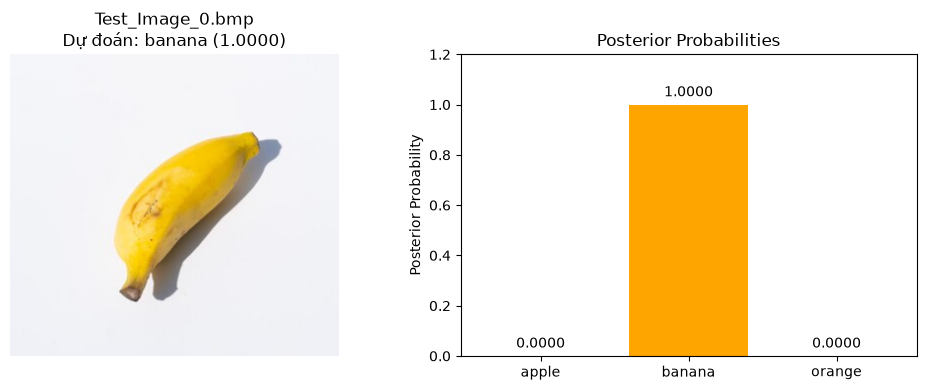

Test_Image_1.bmp -> banana (xác suất: 1.0000)


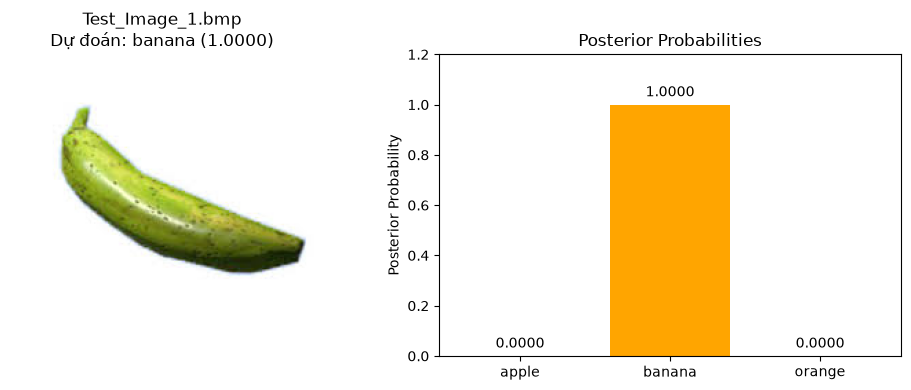

Test_Image_2.bmp -> apple (xác suất: 0.9992)


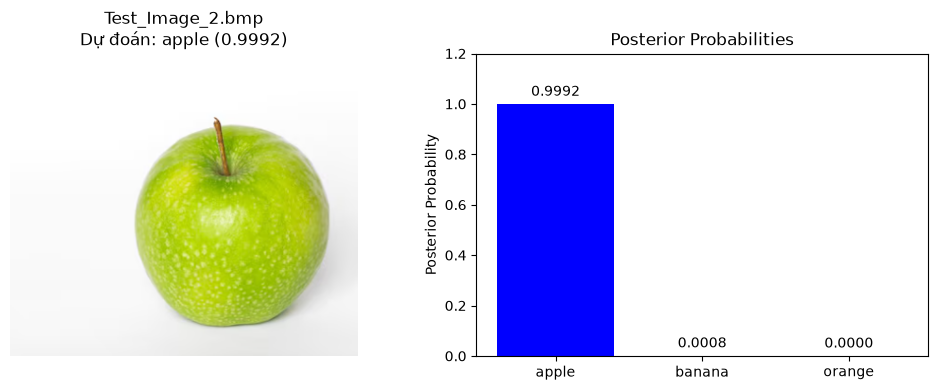

Test_Image_3.bmp -> apple (xác suất: 1.0000)


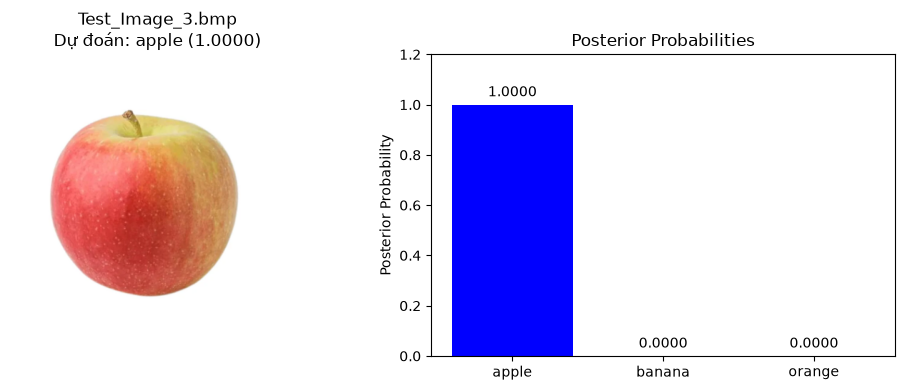

Test_Image_4.bmp -> orange (xác suất: 0.9954)


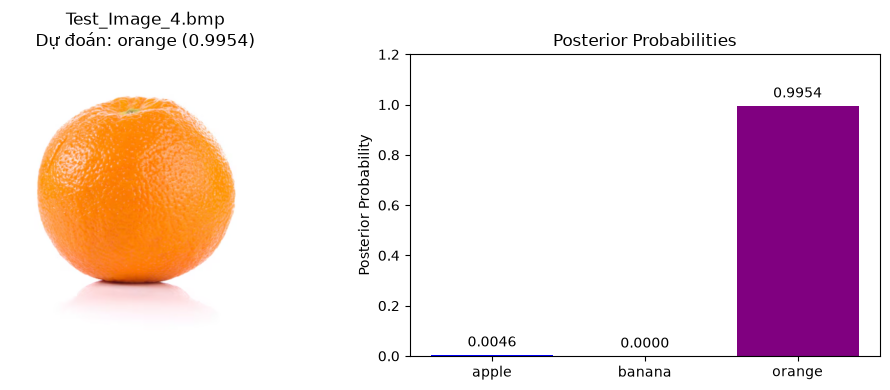

Test_Image_5.bmp -> apple (xác suất: 0.9247)


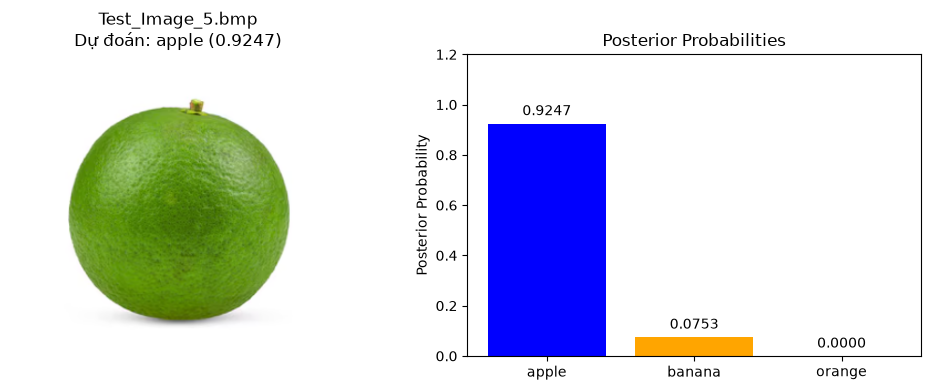

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os   # Thêm thư viện os để duyệt thư mục

# -----------------------------------------------------------
def resize_nearest(img, new_h, new_w):
    old_h, old_w = img.shape[:2]
    row_idx = (np.linspace(0, old_h - 1, new_h)).astype(int)
    col_idx = (np.linspace(0, old_w - 1, new_w)).astype(int)
    grid_y, grid_x = np.meshgrid(row_idx, col_idx, indexing='ij')
    return img[grid_y, grid_x]

# -----------------------------------------------------------
def compute_Roundness(mask):
    area = np.sum(mask)
    padded = np.pad(mask, pad_width=1, mode='constant', constant_values=0)
    perimeter_mask = (
        mask &
        (
            (~padded[:-2, 1:-1]) |
            (~padded[2:, 1:-1])  |
            (~padded[1:-1, :-2]) |
            (~padded[1:-1, 2:])
        )
    )
    perimeter = np.sum(perimeter_mask)
    if perimeter > 0:
        roundness = 4 * np.pi * area / (perimeter ** 2)
    else:
        roundness = 0
    return roundness

# ---------------------------------------------------------------------------------------------
def compute_Elongation(mask):
    ys, xs = np.where(mask)
    coords = np.column_stack((xs, ys))
    cov = np.cov(coords, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    if eigvals[0] > 0:
        elongation = np.sqrt(eigvals[1]) / np.sqrt(eigvals[0])
    else:
        elongation = np.inf
    return elongation

# ---------------------------------------------------------------------------------------------
def FeatureExtraction(img_raw):
    if img_raw.dtype != np.uint8:
        img_raw = (img_raw * 255).astype(np.uint8)
    if img_raw.shape[2] == 4:
        img_raw = img_raw[:, :, :3]
    img = resize_nearest(img_raw, 200, 200)
    gray = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

    hist, _ = np.histogram(gray.ravel(), bins=256, range=(0, 256))
    total = gray.size
    current_max, threshold = 0, 0
    sum_total = np.dot(np.arange(256), hist)
    sum_background, weight_background = 0.0, 0.0

    for i in range(256):
        weight_background += hist[i]
        if weight_background == 0:
            continue
        weight_foreground = total - weight_background
        if weight_foreground == 0:
            break
        sum_background += i * hist[i]
        mean_background = sum_background / weight_background
        mean_foreground = (sum_total - sum_background) / weight_foreground
        between_var = (weight_background * weight_foreground *
                       (mean_background - mean_foreground) ** 2)
        if between_var > current_max:
            current_max = between_var
            threshold = i

    mask = gray < threshold
    roundness = compute_Roundness(mask)
    elongation = compute_Elongation(mask)

    object_pixels = img[mask]
    if object_pixels.size > 0:
        avg_r, avg_g, avg_b = object_pixels.mean(axis=0)
    else:
        avg_r, avg_g, avg_b = -1, -1, -1

    featureVector = np.array([roundness, elongation, avg_r, avg_g, avg_b])
    return featureVector

# ---------------------------------------------------------------------------------------------
def CreateDataset(ImgeNum=5):
    class_folders = ['apple', 'banana', 'orange']
    dataset = []
    for class_name in class_folders:
        for i in range(ImgeNum):
            img_path = 'images/' + class_name + '/image' + str(i) + '.bmp'
            try:
                img_raw = plt.imread(img_path)
                feature_vec = FeatureExtraction(img_raw)
                row = feature_vec.tolist() + [class_name]
                dataset.append(row)
                print(f"Processed {img_path}")
            except Exception as e:
                print(f"Failed {img_path}: {e}")
    columns = ['Roundness', 'Elongation', 'Avg_R', 'Avg_G', 'Avg_B', 'Label']
    df = pd.DataFrame(dataset, columns=columns)
    df.to_csv('fruit_feature_dataset.csv', index=False)
    print("Exported to fruit_feature_dataset.csv")

# ------------------------------------------------------------------------
def normal_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * \
           np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

class NaiveBayesClassifier:
    def __init__(self, _DataLoc, _ClassName):
        self.DataLoc = _DataLoc
        self.ClassName = _ClassName

    def compute_posterior_probability(self, queried_x):
        df = pd.read_csv(self.DataLoc)
        X = df.iloc[:, :-1].to_numpy(dtype=float)
        y = df.iloc[:, -1].to_numpy(str)
        N = y.size
        class_labels = np.unique(y)
        posterior_probs = []
        for c in class_labels:
            P_c = np.sum(y == c) / N
            indices = np.where(y == c)[0]
            likelihood = 1.0
            for i in range(len(queried_x)):
                mu = np.mean(X[indices, i])
                sigma = np.std(X[indices, i])
                sigma = sigma if sigma > 0 else 1e-6
                prob = normal_pdf(queried_x[i], mu, sigma)
                likelihood *= prob
            posterior_probs.append(P_c * likelihood)
        posterior_probs = np.array(posterior_probs)
        total = np.sum(posterior_probs)
        if total == 0:
            posterior_probs = np.zeros_like(posterior_probs)
        else:
            posterior_probs = posterior_probs / total
        return posterior_probs

# ============================
# PHẦN THỰC THI CHÍNH (ĐÃ SỬA)
# ============================

CreateDataset(ImgeNum=5)

# === THAY ĐỔI: Tự động duyệt tất cả ảnh test ===
test_folder = 'images/Test_Images_FruitClassification/'
test_images = [f for f in os.listdir(test_folder) if f.endswith(('.bmp','.jpg','.png'))]
test_images.sort()

class_names = ['apple', 'banana', 'orange']
classifier = NaiveBayesClassifier('fruit_feature_dataset.csv', class_names)

for img_file in test_images:
    img_path = os.path.join(test_folder, img_file)
    img_raw = plt.imread(img_path)
    query = FeatureExtraction(img_raw)
    probs = classifier.compute_posterior_probability(query)
    pred_idx = np.argmax(probs)
    pred_label = class_names[pred_idx]
    max_prob = probs[pred_idx]

    print(f"{img_file} -> {pred_label} (xác suất: {max_prob:.4f})")

    # Vẽ ảnh + biểu đồ (giữ nguyên format cũ)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_raw)
    axes[0].axis('off')
    axes[0].set_title(f'{img_file}\nDự đoán: {pred_label} ({max_prob:.4f})')

    axes[1].bar(class_names, probs, color=['blue','orange','purple'])
    axes[1].set_ylim(0, 1.2)
    axes[1].set_ylabel('Posterior Probability')
    axes[1].set_title('Posterior Probabilities')
    for i, v in enumerate(probs):
        axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()